# Visualize SCALP-lite Embedding

Set `SCALP_INPUT_H5AD` to your input file. Optionally set `SCALP_OUTPUT_H5AD` for the annotated output.

In [23]:
import os
from pathlib import Path

from scalp_lite import ScalpEstimator


def resolve_path(env_name, default):
    path = Path(os.environ.get(env_name, default))
    if path.exists() or path.is_absolute():
        return path
    notebook_relative = Path("..") / path
    return notebook_relative if notebook_relative.exists() else path


# Choose a dataset by setting SCALP_DATASET, or edit selected_dataset below.
DATASETS = {
    # Complete development example: real time slices in Stage and lineage labels.
    "zebrafish": {
        "input": "data/cellrank-zebrafish.h5ad",
        "batch_key": "Stage",
        "label_key": "lineages",
        "preprocess": {"normalize": False, "hvg_flavor": "variance", "create_artificial_batch": False},
        "graph": {"n_neighbors": 15, "intra_fraction": 0.5, "n_inter_edges": 10, "assignment_quantile": 0.3, "symmetrize": True},
    },
    # CellRank pancreas example: developmental day as batch and coarse clusters as labels.
    "pancreas": {
        "input": "data/cellrank-pancreas.h5ad",
        "batch_key": "day",
        "label_key": "clusters_coarse",
        "preprocess": {"normalize": "auto", "hvg_flavor": "cell_ranger", "create_artificial_batch": False},
        "graph": {"n_neighbors": 15, "intra_fraction": 0.5, "n_inter_edges": 3, "assignment_quantile": 0.95, "symmetrize": True},
    },
    # Small smoke-test dataset: no real batch, so preprocessing creates deterministic split_* batches.
    "pbmc3k": {
        "input": "data/scanpy-pbmc3k.h5ad",
        "batch_key": "batch",
        "label_key": "leiden",
        "preprocess": {"normalize": "auto", "hvg_flavor": "cell_ranger", "create_artificial_batch": True},
        "graph": {"n_neighbors": 15, "intra_fraction": 0.5, "n_inter_edges": 1, "assignment_quantile": 0.95, "symmetrize": True},
    },
}

selected_dataset = os.environ.get("SCALP_DATASET", "zebrafish")
dataset = DATASETS[selected_dataset]
# SCALP_INPUT_H5AD can override the selected dataset file.
input_path = resolve_path("SCALP_INPUT_H5AD", dataset["input"])
# SCALP_OUTPUT_H5AD selects where the embedded AnnData file is written.
output_path = Path(os.environ["SCALP_OUTPUT_H5AD"]) if "SCALP_OUTPUT_H5AD" in os.environ else input_path.with_name(f"{input_path.stem}-scalp.h5ad")
# batch_key identifies technical batches, donors, samples, or time points to integrate across.
batch_key = os.environ.get("SCALP_BATCH_KEY", dataset["batch_key"])
# label_key identifies biological cell-type or state labels used for plotting and scoring.
label_key = os.environ.get("SCALP_LABEL_KEY", dataset["label_key"])

# Estimator stores default keys and graph parameters for the workflow.
estimator = ScalpEstimator(
    batch_key=batch_key,
    label_key=label_key,
    # Number of PCA components used as the high-dimensional representation for graph construction.
    n_components=40,
    # Seed used by PCA, subsampling, and graph layout initialization.
    random_state=0,
)

selected_dataset, input_path, batch_key, label_key


In [24]:
preprocess_params = {
    # Number of highly variable genes to keep before PCA.
    "n_top_genes": 2000,
    # Optional cell cap for faster experiments; None keeps all cells.
    "max_cells": None,
    # Optional minimum detected genes per cell; None disables cell filtering.
    "min_cell_genes": None,
    # Remove genes observed fewer than this many total counts.
    "min_gene_counts": 3,
    # Library-size target used by scanpy.pp.normalize_total when normalize is enabled.
    "target_sum": 1e4,
    # Apply scanpy.pp.log1p after normalization when normalize is enabled.
    "log1p": True,
    # Optional batch-aware HVG selection key used by scanpy.pp.highly_variable_genes.
    "hvg_batch_key": None,
    # Number of deterministic split_* batches to create if create_artificial_batch is True.
    "artificial_batch_count": 3,
    # Ordered fallback columns for inferring estimator.label_key when it is absent.
    "label_candidates": ("clusters_coarse", "cell_type", "lineages", "clusters_fine", "clusters", "leiden", "louvain"),
    # Copy input AnnData before preprocessing so the original object is left untouched.
    "copy": True,
    **dataset["preprocess"],
}

adata = estimator.to_data(input_path)
adata = estimator.preprocess(adata, **preprocess_params)
adata


AnnData object with n_obs × n_vars = 2434 × 2000
    obs: 'Stage', 'gt_terminal_states', 'lineages'
    var: 'scalp_lite_hvg_score', 'scalp_lite_selected'
    uns: 'Stage_colors', 'gt_terminal_states_colors', 'lineages_colors'
    obsm: 'X_force_directed', 'X_pca'

In [71]:
graph_params = dataset["graph"]
graph = estimator.data_to_graph(adata, **graph_params)
adata.obsm["X_scalp"] = estimator.graph_to_vector(
    graph,
    # Low-dimensional graph embedding method; UMAP consumes the SCALP graph as precomputed distances.
    method="umap",
    # Number of output coordinates written to adata.obsm["X_scalp"].
    n_components=2,
    # Seed used by UMAP layout initialization.
    random_state=0,
)


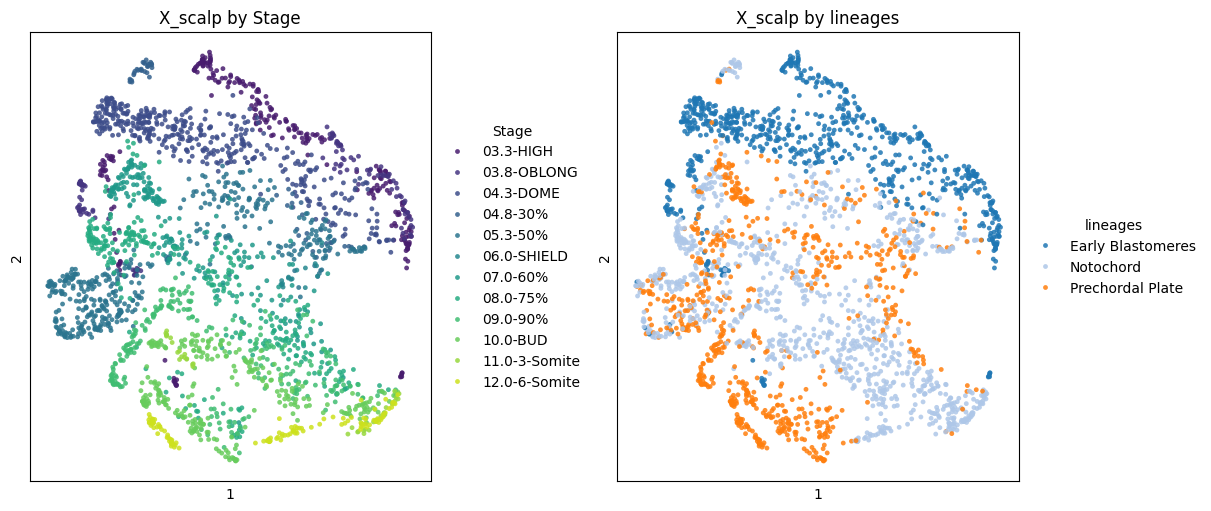

In [72]:
estimator.plot(
    adata,
    # SCALP low-dimensional graph embedding created by graph_to_vector; UMAP here.
    embedding_key="X_scalp",
);


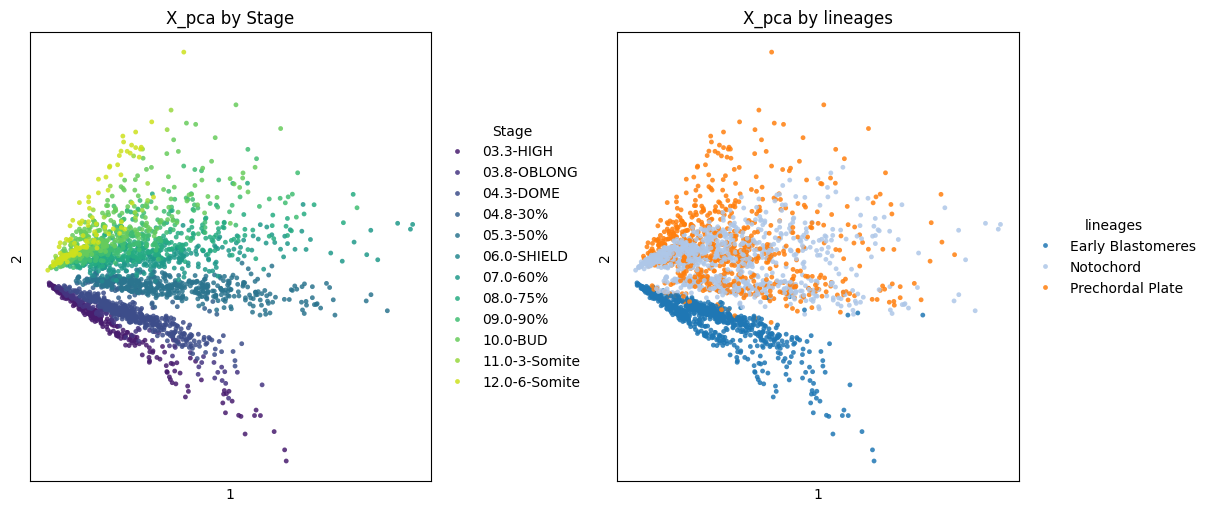

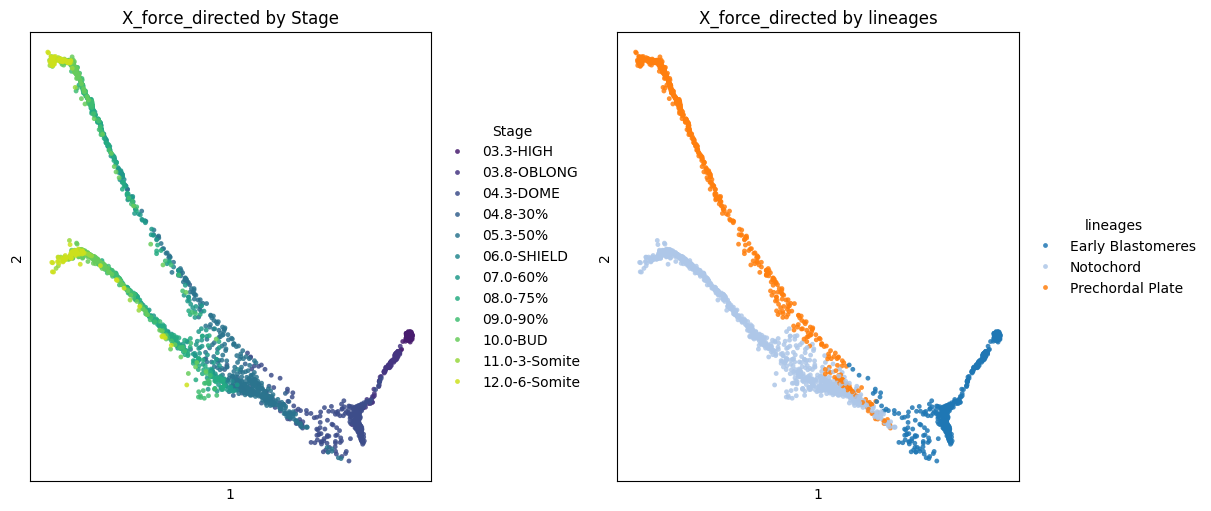

In [73]:
estimator.plot(
    adata,
    # PCA coordinates created or refreshed during preprocessing; used as graph input.
    embedding_key="X_pca",
);
estimator.plot(
    adata,
    # Original CellRank force-directed layout included in the zebrafish file.
    embedding_key="X_force_directed",
);


In [74]:
estimator.save(adata, output_path)
output_path


PosixPath('../data/cellrank-zebrafish-scalp.h5ad')